# Case Study Insights: Gradient Boosting

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of LightGBM and contrast it
with the linear baseline (Ch11) and the tabular deep-learning variant (TabM).
Per-case-study deep dives live in `case_studies/{cs}/13_model_analysis.py`;
this notebook is the comparative view across all nine case studies.

**Learning objectives**

- For each case study, read the highest-IC GBM configuration's average daily
  Spearman IC with HAC 95 % CI on the primary label
- Compare GBM design choices - loss function, tree depth, optimal iteration
  count - and locate the operating regime that achieves the highest IC
- Inspect per-fold IC distributions and the validation to holdout decay where
  the holdout retrain has been run
- Compare full-coverage GBM and linear daily-IC point estimates without
  treating fold summaries as an uncertainty estimator, faceted across labels
- Extend the comparison across labels (horizon view) and across the
  classification ↔ regression metric symmetry
- Inspect feature-importance rank shift versus Ridge, per-fold rank
  stability, and the TabM-vs-GBM-vs-linear three-way picture

**Book reference**: Section 12.6 - Gradient Boosting Across Nine Case Studies.

**Prerequisites**: each case study's `07_gbm.py` pipeline has populated
`run_log/registry.db` for the GBM family. Where present, `tabular_dl.py`
adds TabM rows. Teaching notebooks NB01-NB11 cover the underlying techniques.

In [1]:
"""Case Study Insights: Gradient Boosting cross-case-study registry aggregation."""

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score

In [2]:
# Every comparison below ranks only configurations that covered the same folds
# and the same number of days, so a shorter evaluation window cannot win.
from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_fold_ic_per_cs,
    collect_gbm_checkpoint_trajectories,
    collect_grid_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    load_gbm_feature_importance,
    parse_gbm_config,
    plot_cross_cs_forest,
)
from case_studies.utils.model_analysis import (
    load_metrics_from_registry,
    load_predictions,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_diverging, ml4t_palette

warnings.filterwarnings("ignore")

In [3]:
FAMILY = "gbm"
BASELINE_FAMILY = "linear"
SEED = 42

In [4]:
set_global_seeds(SEED)

## 1. Scope and Coverage

The GBM grid spans four tree-depth profiles
(7 / 15 / 31 / 63 leaves) × 3 regression loss functions (MSE / MAE /
Huber), evaluated at 10 boosting checkpoints per configuration. Direction
labels add a binary-logistic variant. The headline metric is average daily
cross-sectional Spearman IC with a HAC 95 % confidence interval on the primary label
(`prediction_metrics.ic_mean_daily`, `ic_ci_lo`, `ic_ci_hi`, `ic_t_hac`).
The linear family (Ch11) and TabM (`tabular_dl`) are loaded as baselines.

In [5]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    gbm = load_metrics_from_registry(cs, families=[FAMILY])
    tabm = load_metrics_from_registry(cs, families=["tabular_dl"])
    lin = load_metrics_from_registry(cs, families=[BASELINE_FAMILY])
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "gbm_labels": gbm["label"].n_unique() if not gbm.is_empty() else 0,
            "gbm_configs_primary": (
                gbm.filter(pl.col("label") == primary)["config_name"].n_unique()
                if not gbm.is_empty()
                else 0
            ),
            "tabm_configs": tabm["config_name"].n_unique() if not tabm.is_empty() else 0,
            "linear_present": not lin.is_empty(),
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("GBM / TabM / Linear coverage per case study (primary label and labels trained):")
coverage_df

GBM / TabM / Linear coverage per case study (primary label and labels trained):


case_study,primary_label,gbm_labels,gbm_configs_primary,tabm_configs,linear_present
str,str,i64,i64,i64,bool
"""ETFs""","""fwd_ret_21d""",2,15,3,true
"""Crypto""","""fwd_ret_8h""",4,15,3,true
"""NQ100""","""fwd_ret_15m""",4,15,0,true
"""SP500 Eq+Opt""","""fwd_ret_5d""",5,15,3,true
"""US Firms""","""fwd_ret_1m""",3,15,3,true
"""FX""","""fwd_ret_1d""",3,15,3,true
"""CME Futures""","""fwd_ret_5d""",2,15,3,true
"""SP500 Options""","""ret_to_expiry""",1,15,3,true
"""US Equities""","""fwd_ret_1d""",3,15,3,true


## 2. Cross-CS Forest of Highest-IC GBM Configurations

For each case study, the GBM configuration with the highest average daily IC
on the primary label is plotted with its HAC 95 % CI. Filled markers
indicate $|t_{HAC}| > 2$ (CI excludes zero); open markers indicate the CI
overlaps zero.

In [6]:
gbm_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
)
print(
    "Highest-IC GBM configuration per case study (primary label, average daily IC ± HAC 95 % CI):"
)
gbm_rank1.select(
    "short_name",
    "label",
    "config_name",
    pl.col("checkpoint_value").cast(pl.Int64).alias("trees"),
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC GBM configuration per case study (primary label, average daily IC ± HAC 95 % CI):


short_name,label,config_name,trees,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,i64,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""leaves_7_mae""",null,0.044,0.0061,0.0819,2.28,2016
"""Crypto""","""fwd_ret_8h""","""leaves_7_mae""",null,0.011,-0.001,0.0229,1.79,1956
"""NQ100""","""fwd_ret_15m""","""leaves_7_mae""",null,0.006,0.003,0.0089,3.99,64580
"""SP500 Eq+Opt""","""fwd_ret_5d""","""leaves_7_mae""",450,0.0036,-0.0155,0.0228,0.37,504
"""US Firms""","""fwd_ret_1m""","""leaves_15_mae""",null,0.0803,0.063,0.0975,9.21,120
"""FX""","""fwd_ret_1d""","""leaves_63_mae""",null,0.0025,-0.0131,0.018,0.31,2064
"""CME Futures""","""fwd_ret_5d""","""leaves_31_mse""",null,0.0252,-0.0022,0.0525,1.8,1290
"""SP500 Options""","""ret_to_expiry""","""leaves_15_mae""",100,0.0046,-0.0139,0.0232,0.49,484
"""US Equities""","""fwd_ret_1d""","""leaves_63_mae""",null,0.0318,0.0282,0.0354,17.21,4018


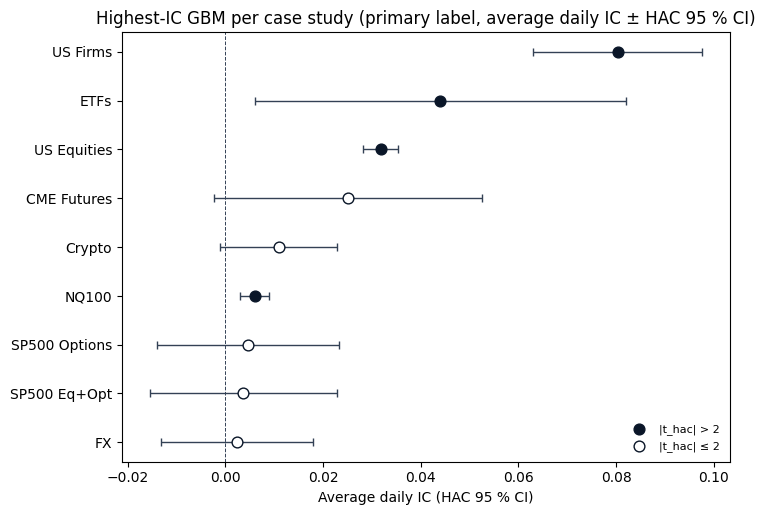

In [7]:
fig, forest_ax = plot_cross_cs_forest(
    gbm_rank1,
    family=FAMILY,
    title="Highest-IC GBM per case study (primary label, average daily IC ± HAC 95 % CI)",
)
forest_ax.set_xlabel("Average daily IC (HAC 95 % CI)")
fig.show()

The next cell derives the cross-case conclusion from the selected rows, naming
no case study or value that it has not just computed.

In [8]:
clear_zero = gbm_rank1.filter((pl.col("ic_ci_lo") > 0) | (pl.col("ic_ci_hi") < 0))[
    "short_name"
].to_list()
overlap_zero = gbm_rank1.filter((pl.col("ic_ci_lo") <= 0) & (pl.col("ic_ci_hi") >= 0))[
    "short_name"
].to_list()
display(
    Markdown(
        "**Computed reading.** "
        f"The GBM HAC interval excludes zero for {len(clear_zero)} of "
        f"{gbm_rank1.height} case studies ({', '.join(clear_zero) or 'none'}). "
        f"It overlaps zero for {', '.join(overlap_zero) or 'none'}."
    )
)

**Computed reading.** The GBM HAC interval excludes zero for 4 of 9 case studies (ETFs, NQ100, US Firms, US Equities). It overlaps zero for Crypto, SP500 Eq+Opt, FX, CME Futures, SP500 Options.

## 3. Within-Family Comparison

How much does each design knob change the IC at the primary label? Three
subsections trace the structured grid: loss function (3a), tree depth (3b),
and checkpoint dynamics (3c). Each is presented with HAC 95 % CIs so the
resolution between operating points stays explicit.

In [9]:
grid_primary = collect_grid_per_cs(
    CASE_STUDY_IDS,
    FAMILY,
    config_parser=parse_gbm_config,
)
grid_regression = grid_primary.filter(pl.col("objective_kind") == "regression")
print(
    f"Per-(CS, config) GBM grid: {grid_primary.height} rows total, "
    f"{grid_regression.height} regression rows."
)

Per-(CS, config) GBM grid: 121 rows total, 121 regression rows.


### 3a. Loss function (MSE / MAE / Huber)

For each case study, the highest-IC configuration is selected within each
regression loss family, then the three (case study, loss) IC values are plotted
side by side with HAC 95 % CI bars.

In [10]:
loss_best = (
    grid_regression.sort("ic_mean_daily", descending=True, nulls_last=True)
    .unique(subset=["case_study", "loss"], keep="first")
    .filter(pl.col("loss").is_in(["mse", "mae", "huber"]))
)

In [11]:
losses_present = ["mse", "mae", "huber"]
loss_colors = {
    "mse": COLORS["neutral"],
    "mae": COLORS["blue"],
    "huber": COLORS["copper"],
}
cs_order = sorted(loss_best["short_name"].unique().to_list())

The helper adds bars and intervals without rendering an unfinished figure
between notebook cells.

In [12]:
def add_loss_bars(ax: plt.Axes, x: np.ndarray, width: float) -> None:
    for i, loss in enumerate(losses_present):
        sub = loss_best.filter(pl.col("loss") == loss)
        ic, err_lo, err_hi = [], [], []
        for cs in cs_order:
            row = sub.filter(pl.col("short_name") == cs)
            if row.height == 0:
                ic.append(np.nan)
                err_lo.append(0.0)
                err_hi.append(0.0)
            else:
                r = row.row(0, named=True)
                ic.append(r["ic_mean_daily"])
                err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
                err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
        ax.bar(
            x + (i - 1) * width,
            np.array(ic, dtype=float),
            width=width,
            yerr=np.vstack([err_lo, err_hi]),
            capsize=2,
            color=loss_colors[loss],
            alpha=0.9,
            label=loss.upper(),
        )

Shared labels and a zero line make the grouped confidence intervals comparable.

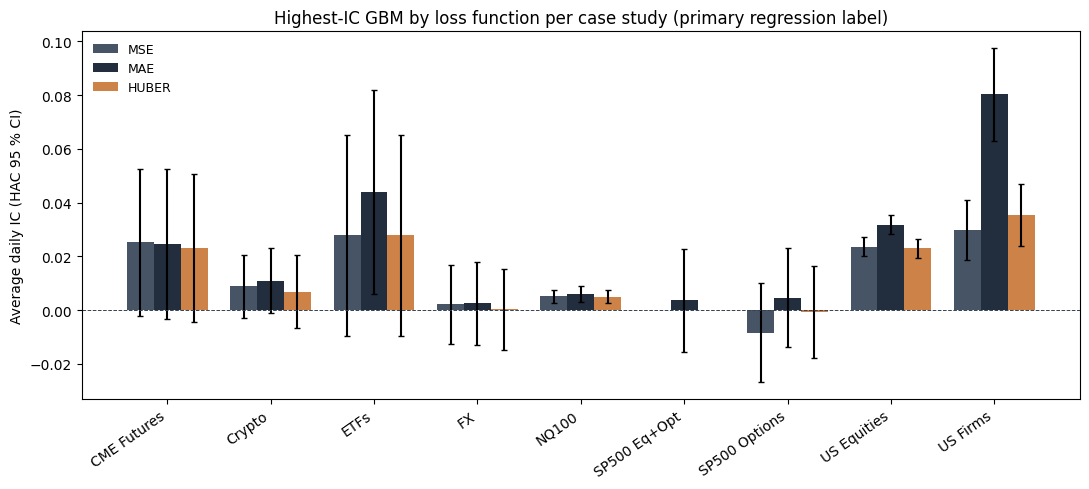

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cs_order))
width = 0.26
add_loss_bars(ax, x, width)
ax.set_xticks(x)
ax.set_xticklabels(cs_order, rotation=35, ha="right")
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_ylabel("Average daily IC (HAC 95 % CI)")
ax.set_title("Highest-IC GBM by loss function per case study (primary regression label)")
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
fig.show()

In [14]:
# Aggregate: which loss achieves the highest of the three on each CS?
loss_top_per_cs = (
    loss_best.sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("short_name")
    .first()
    .group_by("loss")
    .len()
    .rename({"len": "n_cs_with_highest_ic"})
    .sort("n_cs_with_highest_ic", descending=True)
)
print(
    "Loss function achieving the highest IC per case study (count across regression-primary CSs):"
)
loss_top_per_cs

Loss function achieving the highest IC per case study (count across regression-primary CSs):


loss,n_cs_with_highest_ic
str,u32
"""mae""",8
"""mse""",1


In [15]:
loss_count_text = ", ".join(
    f"{row['loss'].upper()}: {row['n_cs_with_highest_ic']}"
    for row in loss_top_per_cs.iter_rows(named=True)
)
display(
    Markdown(
        f"**Computed loss comparison.** Highest-IC loss counts are {loss_count_text}. "
        "The plotted HAC intervals show whether within-panel loss differences are resolved."
    )
)

**Computed loss comparison.** Highest-IC loss counts are MAE: 8, MSE: 1. The plotted HAC intervals show whether within-panel loss differences are resolved.

### 3b. Tree depth heatmap

Within each case study, the highest IC achieved by each leaf profile -
7 / 15 / 31 / 63 leaves - is shown as a heatmap cell. Panels with a
clean diagonal favor a specific depth; panels that are nearly flat across
leaves indicate the depth knob has no resolution at this signal-to-noise
ratio.

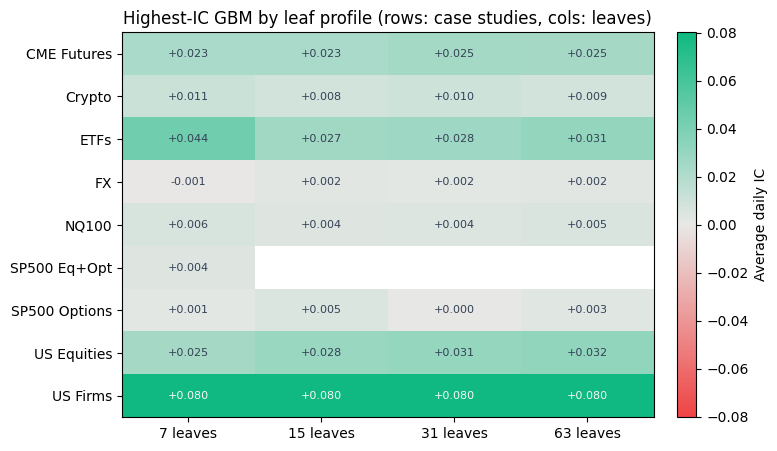

In [16]:
depth_pivot = (
    grid_regression.filter(pl.col("leaves").is_not_null())
    .group_by(["short_name", "leaves"])
    .agg(pl.col("ic_mean_daily").max().alias("ic"))
    .sort(["short_name", "leaves"])
)
ic_matrix = depth_pivot.pivot(index="short_name", on="leaves", values="ic").sort("short_name")
leaf_cols = sorted(
    [c for c in ic_matrix.columns if c != "short_name"],
    key=lambda s: int(s),
)
matrix_values = ic_matrix.select(leaf_cols).to_numpy()
cs_labels = ic_matrix["short_name"].to_list()

fig, ax = plt.subplots(figsize=(7.5, 5))
vmax = float(np.nanmax(np.abs(matrix_values))) if np.isfinite(matrix_values).any() else 0.05
diverging_cmap = LinearSegmentedColormap.from_list("ml4t_diverging", ml4t_diverging())
im = ax.imshow(matrix_values, cmap=diverging_cmap, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(leaf_cols)))
ax.set_xticklabels([f"{c} leaves" for c in leaf_cols])
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(leaf_cols)):
        v = matrix_values[i, j]
        if np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=COLORS["silver"] if abs(v) > 0.6 * vmax else COLORS["neutral"],
            )
ax.set_title("Highest-IC GBM by leaf profile (rows: case studies, cols: leaves)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Average daily IC")
fig.show()

In [17]:
depth_spread = (
    depth_pivot.group_by("short_name")
    .agg(
        min_ic=pl.col("ic").min(),
        max_ic=pl.col("ic").max(),
        n_leaf_profiles=pl.col("leaves").n_unique(),
    )
    .with_columns(spread=pl.col("max_ic") - pl.col("min_ic"))
    .sort("spread", descending=True)
)
widest_depth = depth_spread.row(0, named=True)
display(
    Markdown(
        f"**Computed depth comparison.** {widest_depth['short_name']} has the widest "
        f"leaf-profile range in this snapshot ({widest_depth['spread']:+.4f} IC across "
        f"{widest_depth['n_leaf_profiles']} profiles). Read each range against that panel's "
        "HAC interval rather than treating the largest point estimate as a resolved difference."
    )
)

**Computed depth comparison.** ETFs has the widest leaf-profile range in this snapshot (+0.0175 IC across 4 profiles). Read each range against that panel's HAC interval rather than treating the largest point estimate as a resolved difference.

### 3c. Checkpoint dynamics

Where in the boosting trajectory does the highest-IC checkpoint sit? For
each case study we plot the highest-validation-IC GBM configuration's mean
cross-sectional IC against the boosting checkpoint (number of trees,
50–500). The trajectory is read from `learning_curves.parquet` written by
the boosting runner during training; the final early-stopped checkpoint is
the IC that propagates to the selected row in `prediction_metrics`.

In [18]:
ckpt_df = collect_gbm_checkpoint_trajectories(gbm_rank1)
if ckpt_df.is_empty() or "short_name" not in ckpt_df.columns:
    msg = (
        "collect_gbm_checkpoint_trajectories returned no rows - "
        "learning_curves.parquet is missing for every case study. "
        "Re-run the GBM boosting sweep before this notebook."
    )
    raise RuntimeError(msg)
print(
    f"Per-checkpoint IC for {ckpt_df['short_name'].n_unique()} case studies "
    f"({ckpt_df.height} (CS, iteration) rows)."
)

Per-checkpoint IC for 9 case studies (90 (CS, iteration) rows).


In [19]:
# Order case studies by the iteration of their argmax IC (early to late),
# breaking ties by argmax IC magnitude.
peak_table = (
    ckpt_df.group_by("short_name")
    .agg(
        pl.col("iteration")
        .filter(pl.col("ic_mean") == pl.col("ic_mean").max())
        .first()
        .alias("argmax_iter"),
        pl.col("ic_mean").max().alias("max_ic"),
    )
    .sort(["argmax_iter", "max_ic"], descending=[False, True])
)
cs_order = peak_table["short_name"].to_list()

Small multiples keep each trajectory on its own axis while sharing the tree budget.

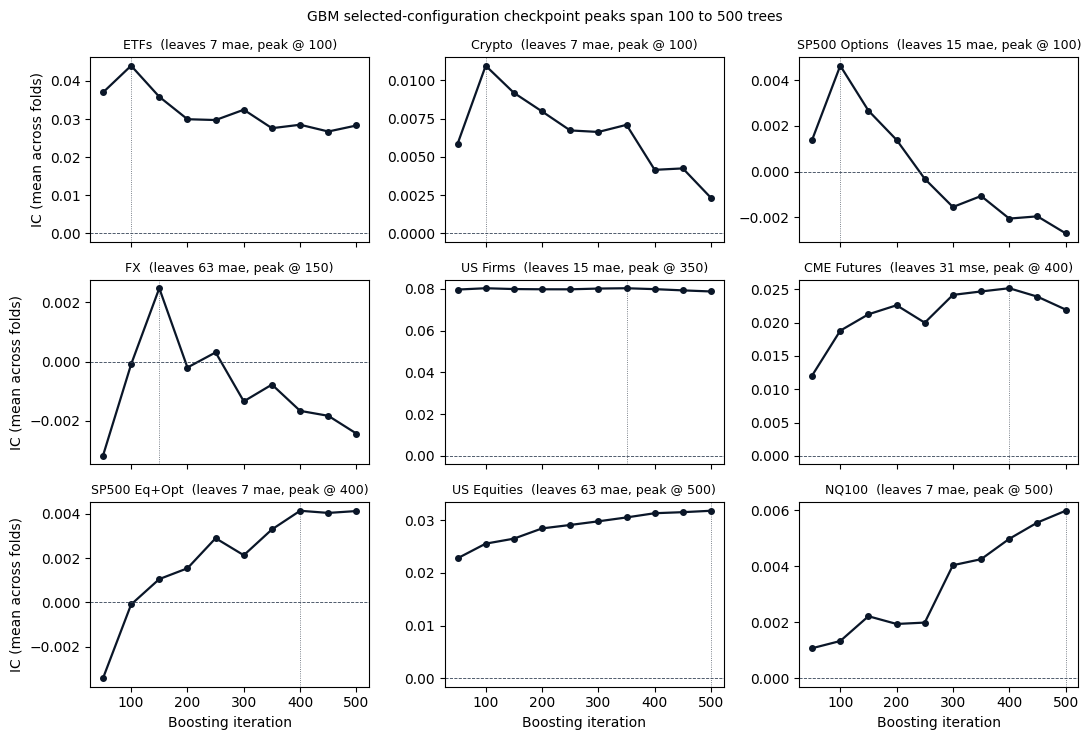

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True)
for i, cs in enumerate(cs_order):
    ax = axes.flat[i]
    sub = ckpt_df.filter(pl.col("short_name") == cs).sort("iteration")
    cfg = sub["config_name"].first()
    x = sub["iteration"].to_numpy()
    ic = sub["ic_mean"].to_numpy()
    color = COLORS["blue"]
    argmax = int(x[ic.argmax()])
    ax.plot(x, ic, "o-", color=color, linewidth=1.6, markersize=4)
    ax.axvline(argmax, color=color, linewidth=0.6, linestyle=":", alpha=0.7)
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.6, linestyle="--")
    ax.set_title(f"{cs}  ({cfg.replace('_', ' ')}, peak @ {argmax})", fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel("IC (mean across folds)")
    if i // 3 == 2:
        ax.set_xlabel("Boosting iteration")
min_peak = int(peak_table["argmax_iter"].min())
max_peak = int(peak_table["argmax_iter"].max())
fig.suptitle(
    f"GBM selected-configuration checkpoint peaks span {min_peak} to {max_peak} trees",
    fontsize=10,
)
fig.tight_layout()
fig.show()

In [21]:
peak_table

short_name,argmax_iter,max_ic
str,i64,f64
"""ETFs""",100,0.043997
"""Crypto""",100,0.010958
"""SP500 Options""",100,0.004642
"""FX""",150,0.002474
"""US Firms""",350,0.080273
"""CME Futures""",400,0.025166
"""SP500 Eq+Opt""",400,0.004143
"""US Equities""",500,0.031797
"""NQ100""",500,0.005986


In [22]:
early_peaks = peak_table.filter(pl.col("argmax_iter") <= 150)["short_name"].to_list()
budget_peaks = peak_table.filter(pl.col("argmax_iter") == max_peak)["short_name"].to_list()
display(
    Markdown(
        f"**Computed checkpoint reading.** {len(early_peaks)} of {peak_table.height} panels "
        f"peak by 150 trees ({', '.join(early_peaks) or 'none'}). "
        f"{len(budget_peaks)} peak at the observed {max_peak}-tree boundary "
        f"({', '.join(budget_peaks) or 'none'})."
    )
)

**Computed checkpoint reading.** 4 of 9 panels peak by 150 trees (ETFs, Crypto, SP500 Options, FX). 2 peak at the observed 500-tree boundary (US Equities, NQ100).

## 4. Stability and Uncertainty

Average daily IC with HAC CI is the headline metric. Per-fold IC is the
stability diagnostic, and the validation→holdout decay is the
generalization diagnostic.

### 4a. Per-fold IC distribution

For each case study's highest-IC GBM configuration, the per-fold IC
distribution is shown as a box-plus-scatter. The reference comparison is
Ch11 §4 - the linear panels frame the GBM panels' fold-stability picture.

In [23]:
gbm_fold = collect_fold_ic_per_cs(gbm_rank1)
gbm_fold_summary = (
    gbm_fold.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC GBM configuration (primary label):")
gbm_fold_summary

Per-fold IC summary for the highest-IC GBM configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""us_firm_characteristics""","""US Firms""",10,0.074805,0.037375,1.0
"""etfs""","""ETFs""",8,0.037805,0.073251,0.75
"""cme_futures""","""CME Futures""",5,0.032726,0.027645,0.8
"""us_equities_panel""","""US Equities""",16,0.032184,0.012614,1.0
"""fx_pairs""","""FX""",8,0.011526,0.020731,0.625
"""crypto_perps_funding""","""Crypto""",2,0.010958,0.007425,1.0
"""nasdaq100_microstructure""","""NQ100""",2,0.005986,0.002335,1.0
"""sp500_options""","""SP500 Options""",2,0.005378,0.027977,0.5
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.003645,0.000793,1.0


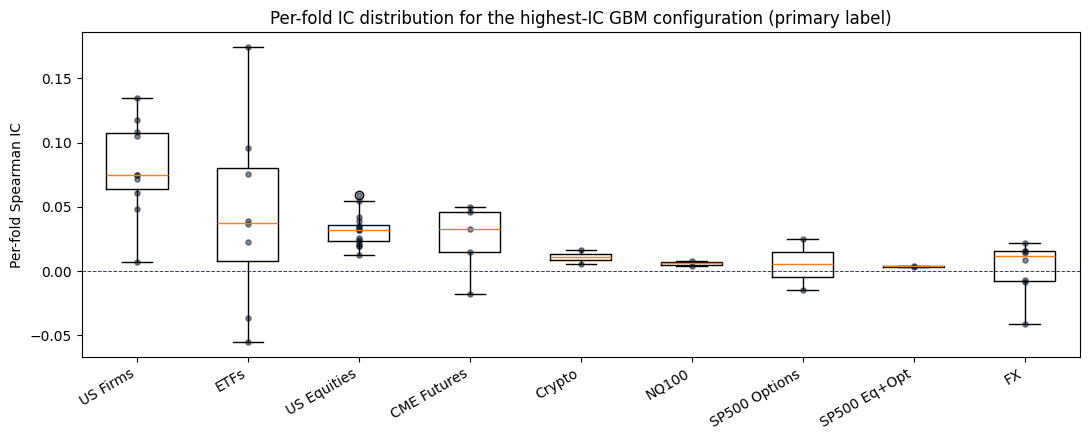

In [24]:
order = gbm_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
present = [c for c in order if c in gbm_fold["short_name"].unique().to_list()]

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [gbm_fold.filter(pl.col("short_name") == cs)["ic"].to_numpy() for cs in present]
positions = np.arange(len(present))
ax.boxplot(data, positions=positions, widths=0.55, showfliers=True)
for i, arr in enumerate(data):
    if len(arr):
        ax.scatter(np.full(len(arr), i), arr, alpha=0.5, s=14, color=COLORS["blue"])
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_ylabel("Per-fold Spearman IC")
ax.set_title("Per-fold IC distribution for the highest-IC GBM configuration (primary label)")
fig.tight_layout()
fig.show()

In [25]:
gbm_positive_majority = gbm_fold_summary.filter(pl.col("pct_positive") > 0.5)[
    "short_name"
].to_list()
gbm_min_folds = int(gbm_fold_summary["n_folds"].min())
display(
    Markdown(
        f"**Computed fold diagnostic.** {len(gbm_positive_majority)} of "
        f"{gbm_fold_summary.height} selected GBM rows have a positive-fold majority "
        f"({', '.join(gbm_positive_majority) or 'none'}). The smallest exact fold panel "
        f"contains {gbm_min_folds} folds; inference remains attached to the daily HAC series."
    )
)

**Computed fold diagnostic.** 8 of 9 selected GBM rows have a positive-fold majority (US Firms, ETFs, CME Futures, US Equities, FX, Crypto, NQ100, SP500 Eq+Opt). The smallest exact fold panel contains 2 folds; inference remains attached to the daily HAC series.

### 4b. Validation → holdout decay dumbbell

Where the holdout retrain has been run, the validation-fold IC and the
nested-holdout IC are linked by a dumbbell. The case studies without GBM
holdout rows in the registry are excluded - the gap is explicit, not
silent.

In [26]:
HOLDOUT_QUERY = """
    SELECT p.prediction_hash, t.training_hash, t.config_name,
           pm.ic_mean_daily, pm.ic_ci_lo, pm.ic_ci_hi, pm.ic_n_days
    FROM prediction_metrics pm
    JOIN prediction_sets p ON pm.prediction_hash = p.prediction_hash
    JOIN training_runs t ON p.training_hash = t.training_hash
    WHERE t.family = ? AND t.label = ? AND t.config_name = ? AND p.split = 'holdout'
"""

In [27]:
def load_selected_holdout(case_study: str, family: str, config_name: str) -> dict | None:
    """Load one unique holdout row for the validation-selected configuration."""
    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    db = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    primary = PRIMARY_LABELS[case_study]
    rows = db.execute(
        HOLDOUT_QUERY,
        (family, primary, config_name),
    ).fetchall()
    db.close()
    valid = [
        row
        for row in rows
        if row[6] is not None
        and row[6] > 0
        and all(value is not None and np.isfinite(value) for value in row[3:7])
    ]
    if not valid:
        return None
    if len(valid) != 1:
        raise RuntimeError(f"Ambiguous holdout rows for {case_study}/{family}/{config_name}")
    row = valid[0]
    return {
        "case_study": case_study,
        "short_name": SHORT_NAMES[case_study],
        "label": primary,
        "prediction_hash": row[0],
        "training_hash": row[1],
        "config_name": row[2],
        "holdout_ic": row[3],
        "holdout_ci_lo": row[4],
        "holdout_ci_hi": row[5],
        "holdout_n_days": row[6],
    }

In [28]:
holdout_rows = []
for selected in gbm_rank1.iter_rows(named=True):
    holdout = load_selected_holdout(
        selected["case_study"],
        FAMILY,
        selected["config_name"],
    )
    if holdout is not None:
        holdout_rows.append(holdout)
holdout_df = pl.DataFrame(holdout_rows) if holdout_rows else pl.DataFrame()
print(
    f"GBM holdout for the validation-selected configuration is available for "
    f"{holdout_df.height} of {gbm_rank1.height} case studies."
)

GBM holdout for the validation-selected configuration is available for 0 of 9 case studies.


Available rows are aligned to the validation-selected configurations before plotting.

Segments and endpoint intervals show the direction and uncertainty of each change.

In [29]:
if not holdout_df.is_empty():
    val_lookup = {r["case_study"]: r for r in gbm_rank1.iter_rows(named=True)}
    decay_rows = []
    for r in holdout_rows:
        v = val_lookup.get(r["case_study"])
        if v is None:
            continue
        decay_rows.append(
            {
                "short_name": r["short_name"],
                "val_ic": v["ic_mean_daily"],
                "val_lo": v["ic_ci_lo"],
                "val_hi": v["ic_ci_hi"],
                "holdout_ic": r["holdout_ic"],
                "holdout_lo": r["holdout_ci_lo"],
                "holdout_hi": r["holdout_ci_hi"],
            }
        )
    decay_df = pl.DataFrame(decay_rows).sort("val_ic", descending=True)

Legend elements distinguish endpoints from the direction of each segment.

In [30]:
def holdout_legend() -> list[Line2D]:
    return [
        Line2D([0], [0], marker="o", color=COLORS["blue"], label="Validation"),
        Line2D([0], [0], marker="D", color=COLORS["amber"], label="Holdout"),
        Line2D([0], [0], color=COLORS["positive"], linewidth=2, label="Holdout ≥ Val"),
        Line2D([0], [0], color=COLORS["negative"], linewidth=2, label="Holdout < Val"),
    ]

The complete dumbbell is assembled in one rendering cell so Jupyter never
captures a partial plot.

In [31]:
def plot_holdout_decay(decay_df: pl.DataFrame) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.5 * decay_df.height + 1)))
    y = np.arange(decay_df.height)
    val, ho = decay_df["val_ic"].to_numpy(), decay_df["holdout_ic"].to_numpy()
    val_lo, val_hi = decay_df["val_lo"].to_numpy(), decay_df["val_hi"].to_numpy()
    ho_lo, ho_hi = decay_df["holdout_lo"].to_numpy(), decay_df["holdout_hi"].to_numpy()
    for i in range(decay_df.height):
        color = COLORS["positive"] if ho[i] >= val[i] else COLORS["negative"]
        ax.plot([val[i], ho[i]], [i, i], color=color, linewidth=2.2, zorder=1)
    ax.errorbar(val, y, xerr=[val - val_lo, val_hi - val], fmt="o", color=COLORS["blue"], capsize=3)
    ax.errorbar(ho, y, xerr=[ho - ho_lo, ho_hi - ho], fmt="D", color=COLORS["amber"], capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(decay_df["short_name"].to_list())
    ax.invert_yaxis()
    ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Average daily IC (HAC 95 % CI)")
    ax.set_title(
        "Validation → holdout dumbbell for the highest-IC GBM configuration (primary label)"
    )
    ax.legend(handles=holdout_legend(), loc="best", frameon=False, fontsize=9)
    fig.tight_layout()
    return fig

The completed chart is rendered only when an exact selected holdout row exists.

In [32]:
if not holdout_df.is_empty():
    fig = plot_holdout_decay(decay_df)
    fig.show()

In [33]:
holdout_names = holdout_df["short_name"].to_list() if not holdout_df.is_empty() else []
display(
    Markdown(
        f"**Computed holdout coverage.** The validation-selected GBM configuration has an "
        f"exact primary-label holdout row for {len(holdout_names)} of {gbm_rank1.height} "
        f"case studies ({', '.join(holdout_names) or 'none'}). No aggregate decay claim is "
        "made when this coverage is sparse."
    )
)

**Computed holdout coverage.** The validation-selected GBM configuration has an exact primary-label holdout row for 0 of 9 case studies (none). No aggregate decay claim is made when this coverage is sparse.

## 5. GBM versus Linear

Per case study, how much does GBM raise the average daily IC over the
strongest full-coverage linear configuration? Two descriptive views compare
the primary-label point estimates (5a) and the same delta across labels (5b).
We do not treat a pair of fold summaries as an uncertainty estimator; each
family's HAC interval comes from its chronological daily IC series.

In [34]:
linear_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family=BASELINE_FAMILY,
)
linear_fold = collect_fold_ic_per_cs(linear_rank1)

In [35]:
delta_primary = (
    gbm_rank1.select(
        "case_study",
        "short_name",
        pl.col("ic_mean_daily").alias("gbm_ic"),
        pl.col("ic_n_days").alias("gbm_days"),
        pl.col("prediction_hash").alias("gbm_prediction_hash"),
    )
    .join(
        linear_rank1.select(
            "case_study",
            pl.col("ic_mean_daily").alias("linear_ic"),
            pl.col("ic_n_days").alias("linear_days"),
            pl.col("prediction_hash").alias("linear_prediction_hash"),
        ),
        on="case_study",
        how="inner",
    )
    .with_columns(delta=pl.col("gbm_ic") - pl.col("linear_ic"))
    .sort("delta", descending=True)
)
print("Descriptive GBM minus Linear daily-IC delta at matched full coverage:")
delta_primary.select(
    "short_name",
    pl.col("gbm_ic").round(4),
    pl.col("linear_ic").round(4),
    pl.col("delta").round(4),
    "gbm_days",
    "linear_days",
)

Descriptive GBM minus Linear daily-IC delta at matched full coverage:


short_name,gbm_ic,linear_ic,delta,gbm_days,linear_days
str,f64,f64,f64,f64,f64
"""US Firms""",0.0803,-0.0052,0.0854,120.0,120.0
"""CME Futures""",0.0252,0.0026,0.0226,1290.0,1290.0
"""US Equities""",0.0318,0.0178,0.014,4018.0,4018.0
"""SP500 Eq+Opt""",0.0036,-0.0059,0.0096,504.0,502.0
"""SP500 Options""",0.0046,-0.0039,0.0086,484.0,484.0
"""Crypto""",0.011,0.0086,0.0024,1956.0,1956.0
"""ETFs""",0.044,0.042,0.002,2016.0,2016.0
"""NQ100""",0.006,0.0049,0.0011,64580.0,64580.0
"""FX""",0.0025,0.0052,-0.0027,2064.0,2064.0


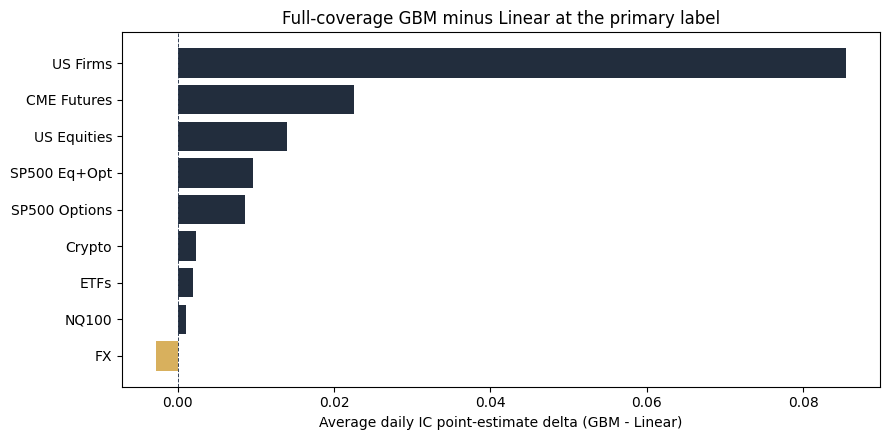

In [36]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(delta_primary.height)
delta = delta_primary["delta"].to_numpy()
colors = [COLORS["blue"] if value >= 0 else COLORS["amber"] for value in delta]
ax.barh(y, delta, color=colors, alpha=0.9)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(delta_primary["short_name"].to_list())
ax.invert_yaxis()
ax.set_xlabel("Average daily IC point-estimate delta (GBM - Linear)")
ax.set_title("Full-coverage GBM minus Linear at the primary label")
fig.tight_layout()
fig.show()

In [37]:
n_positive = delta_primary.filter(pl.col("delta") > 0).height
display(
    Markdown(
        f"**Computed comparison.** GBM has the higher full-coverage daily-IC point estimate "
        f"in {n_positive} of {delta_primary.height} case studies. This chart is descriptive: "
        "the two model families have separate daily-series HAC intervals, so no paired-fold "
        "confidence claim is attached to their difference."
    )
)

**Computed comparison.** GBM has the higher full-coverage daily-IC point estimate in 8 of 9 case studies. This chart is descriptive: the two model families have separate daily-series HAC intervals, so no paired-fold confidence claim is attached to their difference.

### 5b. GBM minus Linear, faceted by label

The primary-label delta is a single horizon per case study. Faceting
across all labels where both families trained shows whether the GBM
advantage (or absence thereof) is consistent across horizons within a
panel.

In [38]:
HORIZON_EXCLUSIONS = {
    (
        "nasdaq100_microstructure",
        "gbm",
        "fwd_ret_5m",
    ): "two complete GBM candidates tie for rank one in the provisional registry",
    (
        "sp500_equity_option_analytics",
        "linear",
        "fwd_ret_risk_adj_5d",
    ): "five complete Linear candidates tie for rank one",
}


def regression_labels(cs: str, family: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[family])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None
        and lbl.startswith("fwd_ret_")
        and "spot" not in lbl
        and (cs, family, lbl) not in HORIZON_EXCLUSIONS
    ]

Both families now pass through the same complete-coverage selector before
their point estimates are joined.

In [39]:
gbm_horizon = collect_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=FAMILY,
    labels=lambda cs: regression_labels(cs, FAMILY),
)
lin_horizon = collect_multi_label_per_cs(
    CASE_STUDY_IDS,
    family=BASELINE_FAMILY,
    labels=lambda cs: regression_labels(cs, BASELINE_FAMILY),
)

Two optional family-label cells are ambiguous: NASDAQ-100 GBM
`fwd_ret_5m` has two complete rank-one candidates, while the S&P
equity-option Linear `fwd_ret_risk_adj_5d` cell has five. Those family-label
cells are excluded rather than resolved arbitrarily. Primary labels and all
unambiguous family-label cells remain in the notebook.

Matched case-study and label rows form the descriptive family-difference panel.

In [40]:
facet_df = (
    gbm_horizon.select(
        "case_study",
        "short_name",
        "label",
        pl.col("ic_mean_daily").alias("gbm_ic"),
    )
    .join(
        lin_horizon.select(
            "case_study",
            "label",
            pl.col("ic_mean_daily").alias("lin_ic"),
        ),
        on=["case_study", "label"],
        how="inner",
    )
    .with_columns(delta=pl.col("gbm_ic") - pl.col("lin_ic"))
    .sort(["short_name", "label"])
)
print(f"GBM-minus-Linear deltas across {facet_df.height} (CS, label) cells:")
facet_df.select(
    "short_name",
    "label",
    pl.col("gbm_ic").round(4).alias("gbm"),
    pl.col("lin_ic").round(4).alias("lin"),
    pl.col("delta").round(4).alias("delta"),
)

GBM-minus-Linear deltas across 18 (CS, label) cells:


short_name,label,gbm,lin,delta
str,str,f64,f64,f64
"""CME Futures""","""fwd_ret_21d""",-0.0041,0.0401,-0.0441
"""CME Futures""","""fwd_ret_5d""",0.0252,0.0026,0.0226
"""Crypto""","""fwd_ret_24h""",0.0177,0.0079,0.0099
"""Crypto""","""fwd_ret_8h""",0.011,0.0086,0.0024
"""ETFs""","""fwd_ret_21d""",0.044,0.042,0.002
…,…,…,…,…
"""US Equities""","""fwd_ret_1d""",0.0318,0.0178,0.014
"""US Equities""","""fwd_ret_21d""",0.0578,0.0286,0.0293
"""US Equities""","""fwd_ret_5d""",0.0426,0.0223,0.0204


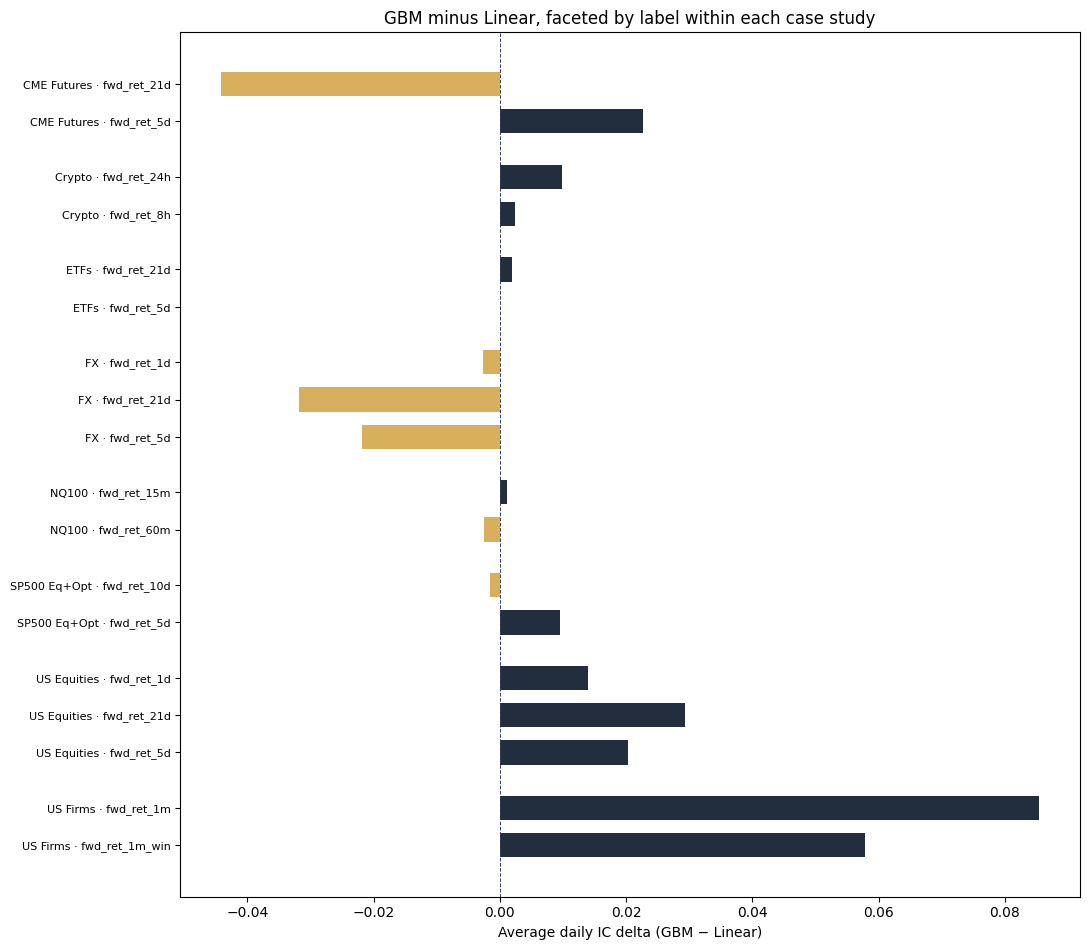

In [41]:
if not facet_df.is_empty():
    cs_sorted = sorted(facet_df["short_name"].unique().to_list())
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * facet_df.height + 1.5)))
    y_off = 0
    yticks, ylabels = [], []
    for cs in cs_sorted:
        sub = facet_df.filter(pl.col("short_name") == cs)
        for r in sub.iter_rows(named=True):
            color = COLORS["blue"] if r["delta"] >= 0 else COLORS["amber"]
            ax.barh(y_off, r["delta"], color=color, height=0.65, alpha=0.9)
            yticks.append(y_off)
            ylabels.append(f"{cs} · {r['label']}")
            y_off += 1
        y_off += 0.5  # gap between case studies
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_xlabel("Average daily IC delta (GBM − Linear)")
    ax.set_title("GBM minus Linear, faceted by label within each case study")
    fig.tight_layout()
    fig.show()

In [42]:
facet_positive = facet_df.filter(pl.col("delta") > 0).height
largest_facet = facet_df.sort("delta", descending=True).row(0, named=True)
smallest_facet = facet_df.sort("delta").row(0, named=True)
display(
    Markdown(
        f"**Computed horizon comparison.** GBM has the higher point estimate in "
        f"{facet_positive} of {facet_df.height} matched case-study/label cells. The range runs "
        f"from {smallest_facet['short_name']} {smallest_facet['label']} "
        f"({smallest_facet['delta']:+.4f}) to {largest_facet['short_name']} "
        f"{largest_facet['label']} ({largest_facet['delta']:+.4f})."
    )
)

**Computed horizon comparison.** GBM has the higher point estimate in 11 of 18 matched case-study/label cells. The range runs from CME Futures fwd_ret_21d (-0.0441) to US Firms fwd_ret_1m (+0.0854).

## 6. Multi-Label Horizon and Metric Symmetry

### 6a. GBM IC across regression labels per case study

In [43]:
HORIZON_DAYS = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_3m": 63.0,
    "fwd_ret_1m_win": 21.0,
    "fwd_ret_risk_adj_5d": 5.0,
}

Only panels with at least two mapped horizons enter the log-scale comparison.

In [44]:
plot_horizon = gbm_horizon.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
).filter(pl.col("horizon_days").is_not_null())
multi_cs = (
    plot_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
plot_horizon = plot_horizon.filter(pl.col("short_name").is_in(multi_cs))

Each line carries its own HAC band; marker and line style supplement the compact palette.

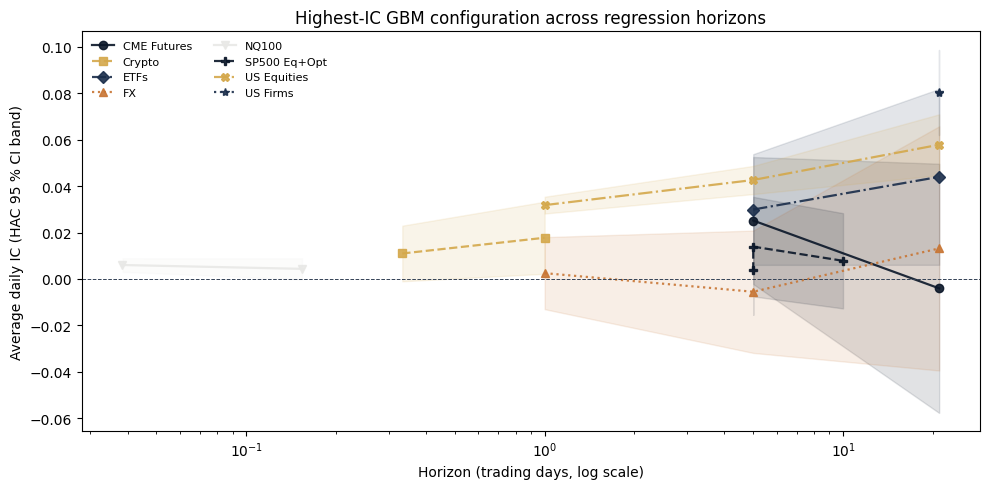

In [45]:
if plot_horizon.height > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = ml4t_palette(5, categorical=True)
    cs_sorted = sorted(plot_horizon["short_name"].unique().to_list())
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
    for idx, cs in enumerate(cs_sorted):
        sub = plot_horizon.filter(pl.col("short_name") == cs).sort("horizon_days")
        if sub.height < 2:
            continue
        x = sub["horizon_days"].to_numpy()
        ic = sub["ic_mean_daily"].to_numpy()
        lo = sub["ic_ci_lo"].to_numpy()
        hi = sub["ic_ci_hi"].to_numpy()
        color = palette[idx % len(palette)]
        ax.fill_between(x, lo, hi, color=color, alpha=0.12)
        ax.plot(
            x,
            ic,
            marker=markers[idx % len(markers)],
            linestyle=linestyles[idx % len(linestyles)],
            color=color,
            label=cs,
            linewidth=1.6,
            markersize=6,
            alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Horizon (trading days, log scale)")
    ax.set_ylabel("Average daily IC (HAC 95 % CI band)")
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_title("Highest-IC GBM configuration across regression horizons")
    ax.legend(loc="best", frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    fig.show()

In [46]:
horizon_ranges = (
    plot_horizon.group_by("short_name")
    .agg(
        n_horizons=pl.len(),
        min_ic=pl.col("ic_mean_daily").min(),
        max_ic=pl.col("ic_mean_daily").max(),
    )
    .with_columns(ic_range=pl.col("max_ic") - pl.col("min_ic"))
    .sort("ic_range", descending=True)
)
display(
    Markdown(
        f"**Computed horizon coverage.** {horizon_ranges.height} case studies have at least "
        "two comparable regression horizons. Their exact IC ranges are shown above; no "
        "cross-horizon trend is asserted for single-horizon panels."
    )
)

**Computed horizon coverage.** 8 case studies have at least two comparable regression horizons. Their exact IC ranges are shown above; no cross-horizon trend is asserted for single-horizon panels.

### 6b. Classification ↔ regression metric symmetry

A GBM trained on a continuous return label has a regression score; the
same model class can be trained on the binary direction label of the
same horizon. Two symmetric questions arise on the case studies that
carry binary direction labels paired to the regression labels:

- **Direction A** - the GBM classification model's score, evaluated as
  IC against the *continuous* return, asks whether the directional
  classifier is also a useful *cross-sectional ranker*. Read from
  `prediction_metrics.ic_mean_daily` for `task_type='classification'` rows.
- **Direction B** - the GBM regression model's score, evaluated as AUC
  against the *binary* direction, asks whether the continuous regression
  score is also a useful *binary classifier*. Computed on the fly here
  from raw OOF predictions.

Restricted to the registered binary-label pairs below. Ternary direction
labels (including NASDAQ-100 `fwd_dir_15m`, Crypto `fwd_dir_8h_3c`, and US
Firms `fwd_class_1m`) need a multiclass score and remain out of scope. This
mirrors Ch11 §6b for the linear family.

In [47]:
SYMMETRY_PAIRS: dict[str, list[tuple[str, str]]] = {
    "crypto_perps_funding": [("fwd_ret_8h", "fwd_dir_8h")],
    "sp500_equity_option_analytics": [
        ("fwd_ret_5d", "fwd_dir_5d"),
        ("fwd_ret_10d", "fwd_dir_10d"),
    ],
}

Binary labels align on canonical timestamp and symbol before the regression
score is evaluated as a direction classifier.

In [48]:


def load_binary_label(cs: str, dir_label: str) -> pl.DataFrame:
    p = get_case_study_dir(cs) / "labels" / f"{dir_label}.parquet"
    if not p.exists():
        return pl.DataFrame()
    df = pl.read_parquet(p)
    return df.rename({dir_label: "y_dir"}).select("timestamp", "symbol", "y_dir")

In [49]:
def gbm_direction_b_auc(selected: dict, dir_label: str) -> dict | None:
    cs = selected["case_study"]
    reg_label = selected["label"]
    preds = load_predictions(
        cs,
        family=FAMILY,
        label=reg_label,
        config_name=selected["config_name"],
        checkpoint_value=selected["checkpoint_value"],
        split="validation",
    ).filter(pl.col("prediction_hash") == selected["prediction_hash"])
    if preds.height == 0:
        return None
    dir_df = load_binary_label(cs, dir_label)
    if dir_df.is_empty():
        return None
    canonical_types = {"timestamp": pl.Datetime("ms"), "symbol": pl.Utf8}
    for column, dtype in canonical_types.items():
        if preds[column].dtype != dir_df[column].dtype:
            preds = preds.with_columns(pl.col(column).cast(dtype))
            dir_df = dir_df.with_columns(pl.col(column).cast(dtype))
    merged = preds.join(dir_df, on=["timestamp", "symbol"], how="inner")
    domain = set(merged["y_dir"].unique().drop_nulls().to_list())
    if not domain.issubset({0, 1}):
        print(f"  SKIP {cs}/{dir_label}: y_dir domain {domain} is not binary {{0,1}}")
        return None
    merged = merged.filter(pl.col("y_dir").is_in([0, 1]) & pl.col("y_score").is_not_null())
    if merged.height == 0 or merged["y_dir"].n_unique() < 2:
        return None
    auc = float(roc_auc_score(merged["y_dir"].to_numpy(), merged["y_score"].to_numpy()))
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "reg_label": reg_label,
        "dir_label": dir_label,
        "reg_config": selected["config_name"],
        "reg_prediction_hash": selected["prediction_hash"],
        "reg_score_auc": auc,
        "n": merged.height,
    }

In [50]:
direction_labels = {
    cs: [direction_label for _, direction_label in pairs] for cs, pairs in SYMMETRY_PAIRS.items()
}
direction_rank1 = collect_multi_label_per_cs(
    SYMMETRY_PAIRS,
    family=FAMILY,
    labels=lambda cs: direction_labels[cs],
)

Direction A comes from the selected classification row; Direction B uses the
exact selected regression prediction hash against the paired binary label.

In [51]:
sym_rows = []
for cs, pairs in SYMMETRY_PAIRS.items():
    for reg_lbl, dir_lbl in pairs:
        cls_ic = cls_lo = cls_hi = cls_t = cls_cfg = None
        cls_selected = direction_rank1.filter(
            (pl.col("case_study") == cs) & (pl.col("label") == dir_lbl)
        )
        if not cls_selected.is_empty():
            top = cls_selected.row(0, named=True)
            cls_ic = top["ic_mean_daily"]
            cls_lo = top.get("ic_ci_lo")
            cls_hi = top.get("ic_ci_hi")
            cls_t = top.get("ic_t_hac")
            cls_cfg = top["config_name"]
        reg_selected = gbm_horizon.filter(
            (pl.col("case_study") == cs) & (pl.col("label") == reg_lbl)
        )
        b = (
            gbm_direction_b_auc(reg_selected.row(0, named=True), dir_lbl)
            if not reg_selected.is_empty()
            else None
        )
        sym_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "reg_label": reg_lbl,
                "dir_label": dir_lbl,
                "cls_config": cls_cfg,
                "cls_score_ic": cls_ic,
                "cls_score_ic_lo": cls_lo,
                "cls_score_ic_hi": cls_hi,
                "cls_score_ic_t": cls_t,
                "reg_config": (b or {}).get("reg_config"),
                "reg_score_auc": (b or {}).get("reg_score_auc"),
                "n_b": (b or {}).get("n"),
            }
        )

The combined table keeps both metric directions and their selected identities visible.

In [52]:
sym_df = pl.DataFrame(
    sym_rows,
    schema_overrides={
        "cls_score_ic": pl.Float64,
        "cls_score_ic_lo": pl.Float64,
        "cls_score_ic_hi": pl.Float64,
        "cls_score_ic_t": pl.Float64,
        "reg_score_auc": pl.Float64,
        "n_b": pl.Int64,
    },
)
print("Direction A (GBM classification score → IC) and Direction B (GBM regression score → AUC):")
sym_df.select(
    "short_name",
    "reg_label",
    "dir_label",
    pl.col("cls_score_ic").round(4).alias("A_ic"),
    pl.col("cls_score_ic_lo").round(4).alias("A_lo"),
    pl.col("cls_score_ic_hi").round(4).alias("A_hi"),
    pl.col("cls_score_ic_t").round(2).alias("A_t"),
    pl.col("reg_score_auc").round(4).alias("B_auc"),
)

Direction A (GBM classification score → IC) and Direction B (GBM regression score → AUC):


short_name,reg_label,dir_label,A_ic,A_lo,A_hi,A_t,B_auc
str,str,str,f64,f64,f64,f64,f64
"""Crypto""","""fwd_ret_8h""","""fwd_dir_8h""",0.0197,0.0076,0.0317,3.2,null
"""SP500 Eq+Opt""","""fwd_ret_5d""","""fwd_dir_5d""",0.004,-0.0131,0.0211,0.46,null
"""SP500 Eq+Opt""","""fwd_ret_10d""","""fwd_dir_10d""",-0.0103,-0.036,0.0153,-0.79,null


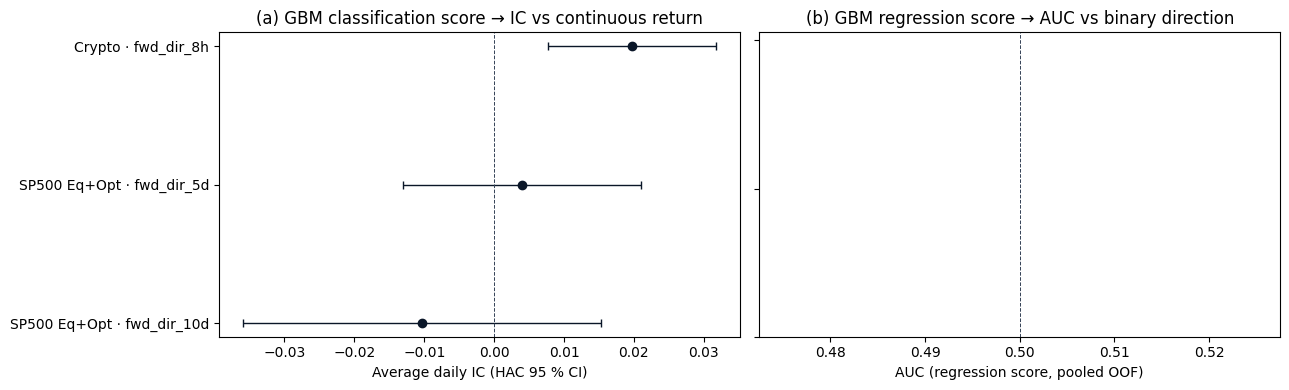

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
labels_y = [f"{r['short_name']} · {r['dir_label']}" for r in sym_df.iter_rows(named=True)]
y = np.arange(sym_df.height)

ax = axes[0]
ic = sym_df["cls_score_ic"].to_numpy()
lo = sym_df["cls_score_ic_lo"].to_numpy()
hi = sym_df["cls_score_ic_hi"].to_numpy()
ax.errorbar(
    ic,
    y,
    xerr=[ic - lo, hi - ic],
    fmt="o",
    color=COLORS["blue"],
    capsize=3,
    lw=1,
)
ax.axvline(0, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels_y)
ax.invert_yaxis()
ax.set_xlabel("Average daily IC (HAC 95 % CI)")
ax.set_title("(a) GBM classification score → IC vs continuous return")

ax = axes[1]
auc = sym_df["reg_score_auc"].to_numpy()
ax.scatter(auc, y, color=COLORS["copper"], s=60, zorder=3)
ax.axvline(0.5, color=COLORS["neutral"], lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel("AUC (regression score, pooled OOF)")
ax.set_title("(b) GBM regression score → AUC vs binary direction")

fig.tight_layout()
fig.show()

In [54]:
direction_a_positive = sym_df.filter(pl.col("cls_score_ic") > 0).height
direction_b_valid = sym_df.filter(pl.col("reg_score_auc").is_not_null())
max_auc_distance = (
    float((direction_b_valid["reg_score_auc"] - 0.5).abs().max())
    if not direction_b_valid.is_empty()
    else float("nan")
)
display(
    Markdown(
        f"**Computed metric symmetry.** Direction A is positive in {direction_a_positive} of "
        f"{sym_df.height} matched cells. Direction B is available in {direction_b_valid.height} "
        f"cells, with maximum absolute distance from 0.5 of {max_auc_distance:.4f}."
    )
)

**Computed metric symmetry.** Direction A is positive in 2 of 3 matched cells. Direction B is available in 0 cells, with maximum absolute distance from 0.5 of nan.

## 7. Interpretability

Three diagnostics use saved booster + Ridge coefficient artifacts: feature-
importance rank shift versus Ridge (7a), per-fold rank stability of GBM
importances (7b), and the TabM-vs-GBM-vs-Linear three-way picture (7c).

In [55]:
NON_FEATURE_COLS = {"timestamp", "symbol", "stock_id", "product", "position", "instrument_id"}
IMPORTANCE_CASES = ["etfs", "sp500_options", "us_firm_characteristics", "us_equities_panel"]


def _load_ridge_importance(cs: str, training_hash: str, config_name: str) -> dict[str, float]:
    """Mean absolute coefficients from one selected linear training identity."""
    coef_path = (
        get_case_study_dir(cs) / "run_log" / "training" / training_hash / "coefficients.parquet"
    )
    if not coef_path.exists():
        return {}
    coefficients = pl.read_parquet(coef_path)
    if "config_name" in coefficients.columns:
        coefficients = coefficients.filter(pl.col("config_name") == config_name)
    ridge_only = coefficients.filter(pl.col("feature") != "_intercept_")
    if ridge_only.is_empty():
        return {}
    return dict(
        ridge_only.group_by("feature")
        .agg(pl.col("coefficient").abs().mean().alias("abs_coef"))
        .sort("abs_coef", descending=True)
        .iter_rows()
    )

Rank dictionaries use the same feature intersection for both families.

In [56]:
def _feature_ranks(
    gbm_imp_df: pl.DataFrame,
    ridge_imp: dict[str, float],
) -> tuple[dict[str, int], dict[str, int]]:
    gbm_imp = dict(
        gbm_imp_df.group_by("feature").agg(pl.col("importance").mean().alias("imp")).iter_rows()
    )
    common = set(gbm_imp) & set(ridge_imp)
    gbm_order = sorted(common, key=gbm_imp.get, reverse=True)
    ridge_order = sorted(common, key=ridge_imp.get, reverse=True)
    return (
        {feature: rank for rank, feature in enumerate(gbm_order, 1)},
        {feature: rank for rank, feature in enumerate(ridge_order, 1)},
    )

### 7a. Feature importance - GBM versus Ridge rank shift

For each case study with both saved boosters and Ridge coefficient
parquets, features are ranked by GBM gain importance (mean across folds)
and by Ridge mean |coefficient|. The rank shift `lin_rank − gbm_rank` is
positive for features GBM promotes over Ridge (typically interaction or
regime features) and negative for features Ridge promotes over GBM
(typically monotonic predictors).

In [57]:
def feature_rank_shift(cs: str) -> dict | None:
    gbm_selected = gbm_rank1.filter(pl.col("case_study") == cs)
    linear_selected = linear_rank1.filter(pl.col("case_study") == cs)
    if gbm_selected.is_empty() or linear_selected.is_empty():
        return None
    gbm_row = gbm_selected.row(0, named=True)
    linear_row = linear_selected.row(0, named=True)
    gbm_imp_df = load_gbm_feature_importance(
        cs,
        gbm_row["training_hash"],
        gbm_row["config_name"],
        top_n=50,
    )
    if gbm_imp_df.is_empty():
        return None
    ridge_imp = _load_ridge_importance(cs, linear_row["training_hash"], linear_row["config_name"])
    gbm_ranks, ridge_ranks = _feature_ranks(gbm_imp_df, ridge_imp)
    if not gbm_ranks:
        return None
    shifts = pl.DataFrame(
        [
            {
                "feature": f,
                "gbm_rank": gbm_ranks[f],
                "ridge_rank": ridge_ranks[f],
                "rank_shift": ridge_ranks[f] - gbm_ranks[f],
            }
            for f in gbm_ranks
        ]
    )
    min_shift = shifts["rank_shift"].min()
    return {
        "short_name": SHORT_NAMES[cs],
        "n_common_features": shifts.height,
        "median_abs_shift": float(shifts["rank_shift"].abs().median()),
        "max_gbm_promotion": int(shifts["rank_shift"].max() or 0),
        "max_ridge_promotion": int(-min_shift if min_shift else 0),
        "_shifts": shifts,
    }

Apply the comparison only where both exact selected artifact sets exist.

In [58]:
rank_shift_summary = [
    entry for cs in IMPORTANCE_CASES if (entry := feature_rank_shift(cs)) is not None
]

print(f"Computed GBM-vs-Ridge rank shifts for {len(rank_shift_summary)} case studies.")
shift_summary_df = (
    pl.DataFrame(
        [{k: v for k, v in r.items() if not k.startswith("_")} for r in rank_shift_summary]
    )
    if rank_shift_summary
    else pl.DataFrame()
)
shift_summary_df

Computed GBM-vs-Ridge rank shifts for 4 case studies.


short_name,n_common_features,median_abs_shift,max_gbm_promotion,max_ridge_promotion
str,i64,f64,i64,i64
"""ETFs""",50,8.0,32,38
"""SP500 Options""",50,11.0,43,27
"""US Firms""",50,11.0,28,37
"""US Equities""",50,11.5,30,38


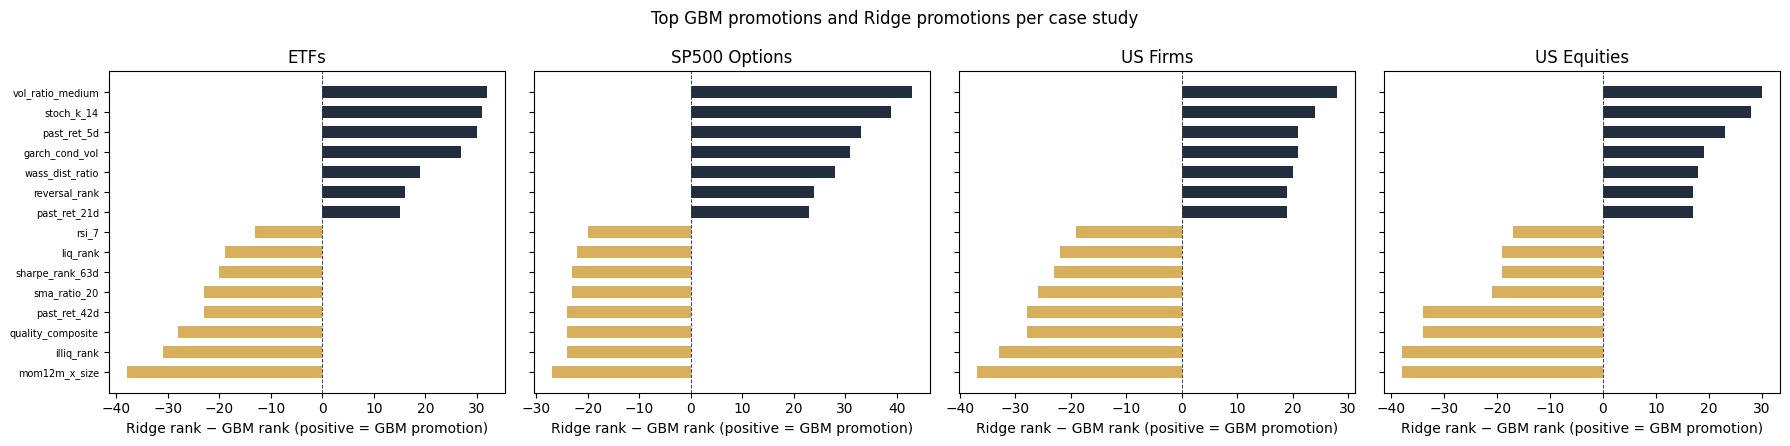

In [59]:
if rank_shift_summary:
    fig, axes = plt.subplots(
        1,
        len(rank_shift_summary),
        figsize=(4.5 * len(rank_shift_summary), 4.5),
        sharey=True,
    )
    if len(rank_shift_summary) == 1:
        axes = [axes]
    for ax, entry in zip(axes, rank_shift_summary, strict=False):
        s = entry["_shifts"].sort("rank_shift", descending=True)
        n_show = min(15, s.height)
        top_promotions = s.head(n_show // 2)
        bot_promotions = s.tail(n_show - top_promotions.height)
        plot_set = pl.concat([top_promotions, bot_promotions]).sort("rank_shift", descending=False)
        y = np.arange(plot_set.height)
        colors = [
            COLORS["blue"] if v > 0 else COLORS["amber"] for v in plot_set["rank_shift"].to_list()
        ]
        ax.barh(y, plot_set["rank_shift"].to_numpy(), color=colors, height=0.6, alpha=0.9)
        ax.set_yticks(y)
        ax.set_yticklabels(plot_set["feature"].to_list(), fontsize=7)
        ax.axvline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
        ax.set_xlabel("Ridge rank − GBM rank (positive = GBM promotion)")
        ax.set_title(entry["short_name"])
    fig.suptitle("Top GBM promotions and Ridge promotions per case study")
    fig.tight_layout()
    fig.show()

Rank shifts are descriptive diagnostics of how the two model families use
the shared feature library. They do not establish that a promoted feature
causes the GBM-minus-linear performance difference.

### 7b. Per-fold feature-rank stability

For each case study, the top-10 GBM features by mean gain are identified,
then re-ranked within each fold. Mean pairwise Spearman rank correlation
across folds quantifies whether the same features dominate every fold or
whether the top-N rotates regime to regime.

In [60]:
def pairwise_rank_correlation(fold_arrays: list[np.ndarray]) -> tuple[float, float] | None:
    """Return mean and minimum pairwise feature-rank correlation."""
    ranks = [np.argsort(np.argsort(-values)) for values in fold_arrays]
    pairs = [
        np.corrcoef(ranks[i], ranks[j])[0, 1]
        for i in range(len(ranks))
        for j in range(i + 1, len(ranks))
        if ranks[i].size > 1 and ranks[j].size > 1
    ]
    if not pairs:
        return None
    return float(np.mean(pairs)), float(np.min(pairs))

Each row uses only folds attached to the exact selected training identity.

In [61]:
def feature_rank_stability(cs: str) -> dict | None:
    selected = gbm_rank1.filter(pl.col("case_study") == cs)
    if selected.is_empty():
        return None
    row = selected.row(0, named=True)
    gbm_imp_df = load_gbm_feature_importance(
        cs,
        row["training_hash"],
        row["config_name"],
        top_n=30,
    )
    if gbm_imp_df.is_empty():
        return None
    top_features = (
        gbm_imp_df.group_by("feature")
        .agg(pl.col("importance").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(10)["feature"]
        .to_list()
    )
    sub = (
        gbm_imp_df.filter(pl.col("feature").is_in(top_features))
        .group_by(["feature", "fold_id"])
        .agg(pl.col("importance").mean())
    )
    pivot = sub.pivot(index="feature", on="fold_id", values="importance").drop_nulls()
    fold_cols = [c for c in pivot.columns if c != "feature"]
    if len(fold_cols) < 2 or pivot.height < 3:
        return None
    correlations = pairwise_rank_correlation([pivot[c].to_numpy() for c in fold_cols])
    if correlations is None:
        return None
    mean_corr, min_corr = correlations
    return {
        "short_name": SHORT_NAMES[cs],
        "n_folds": len(fold_cols),
        "n_top_features": len(top_features),
        "mean_pairwise_rank_corr": mean_corr,
        "min_pairwise_rank_corr": min_corr,
    }

The diagnostic remains absent when fewer than two complete folds or three
top features are available.

In [62]:
stability_rows = [
    entry for cs in IMPORTANCE_CASES if (entry := feature_rank_stability(cs)) is not None
]

stability_df = pl.DataFrame(stability_rows)
print("Per-fold feature-rank stability for the top-10 GBM features per case study:")
stability_df

Per-fold feature-rank stability for the top-10 GBM features per case study:


short_name,n_folds,n_top_features,mean_pairwise_rank_corr,min_pairwise_rank_corr
str,i64,i64,f64,f64
"""ETFs""",8,10,0.498268,0.066667
"""SP500 Options""",2,10,0.50303,0.50303
"""US Firms""",10,10,0.722559,0.466667
"""US Equities""",16,10,0.041717,-0.878788


In [63]:
if not stability_df.is_empty():
    most_stable = stability_df.sort("mean_pairwise_rank_corr", descending=True).row(0, named=True)
    least_stable = stability_df.sort("mean_pairwise_rank_corr").row(0, named=True)
    display(
        Markdown(
            f"**Computed feature stability.** Mean pairwise top-feature rank correlation spans "
            f"{least_stable['mean_pairwise_rank_corr']:+.2f} ({least_stable['short_name']}) to "
            f"{most_stable['mean_pairwise_rank_corr']:+.2f} ({most_stable['short_name']}). "
            "Treat this as a regime-stability diagnostic, not as model-performance inference."
        )
    )

**Computed feature stability.** Mean pairwise top-feature rank correlation spans +0.04 (US Equities) to +0.72 (US Firms). Treat this as a regime-stability diagnostic, not as model-performance inference.

### 7c. TabM versus GBM versus Linear - three-way picture

TabM (Gorishniy et al., ICLR 2025) is a rank-one adapter MLP ensemble that
operates on the same flat feature matrix as GBMs. For each case study
the highest average daily IC across configurations within each of the
three families is shown side by side at the primary label.

In [64]:
tabm_rank1 = collect_rank1_per_cs(
    CASE_STUDY_IDS,
    family="tabular_dl",
)

three_way = (
    gbm_rank1.select("case_study", "short_name", pl.col("ic_mean_daily").alias("gbm_ic"))
    .join(
        linear_rank1.select("case_study", pl.col("ic_mean_daily").alias("lin_ic")),
        on="case_study",
        how="left",
    )
    .join(
        tabm_rank1.select("case_study", pl.col("ic_mean_daily").alias("tabm_ic")),
        on="case_study",
        how="left",
    )
    .sort("gbm_ic", descending=True)
)
print("Linear / GBM / TabM highest-validation-IC average daily IC per case study (primary label):")
three_way.select(
    "short_name",
    pl.col("lin_ic").round(4).alias("linear"),
    pl.col("gbm_ic").round(4).alias("gbm"),
    pl.col("tabm_ic").round(4).alias("tabm"),
)

Linear / GBM / TabM highest-validation-IC average daily IC per case study (primary label):


short_name,linear,gbm,tabm
str,f64,f64,f64
"""US Firms""",-0.0052,0.0803,0.0308
"""ETFs""",0.042,0.044,0.0341
"""US Equities""",0.0178,0.0318,0.0167
"""CME Futures""",0.0026,0.0252,0.0078
"""Crypto""",0.0086,0.011,0.003
"""NQ100""",0.0049,0.006,null
"""SP500 Options""",-0.0039,0.0046,-0.0014
"""SP500 Eq+Opt""",-0.0059,0.0036,0.0114
"""FX""",0.0052,0.0025,0.0096


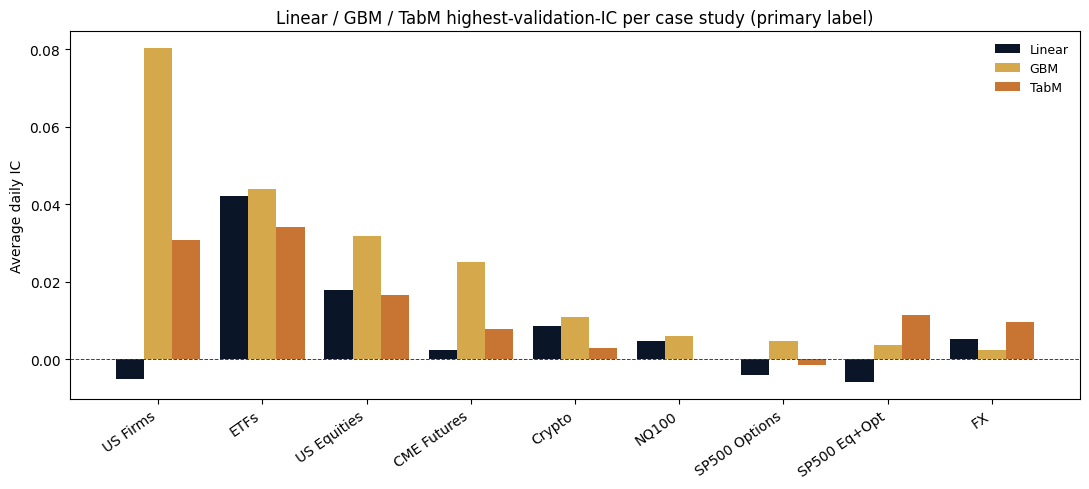

In [65]:
fig, ax = plt.subplots(figsize=(11, 5))
cs_sorted = three_way["short_name"].to_list()
x = np.arange(len(cs_sorted))
width = 0.27
fam_colors = {
    "linear": COLORS["blue"],
    "gbm": COLORS["amber"],
    "tabm": COLORS["copper"],
}
ax.bar(
    x - width,
    three_way["lin_ic"].to_numpy(),
    width=width,
    color=fam_colors["linear"],
    label="Linear",
)
ax.bar(x, three_way["gbm_ic"].to_numpy(), width=width, color=fam_colors["gbm"], label="GBM")
ax.bar(
    x + width, three_way["tabm_ic"].to_numpy(), width=width, color=fam_colors["tabm"], label="TabM"
)
ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(cs_sorted, rotation=35, ha="right")
ax.set_ylabel("Average daily IC")
ax.set_title("Linear / GBM / TabM highest-validation-IC per case study (primary label)")
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
fig.show()

The comparison remains coverage-explicit: a missing family stays null and is
never replaced by a result from another label or an incomplete validation span.

In [66]:
tabm_present = set(tabm_rank1["case_study"].to_list())
tabm_missing = [SHORT_NAMES[cs] for cs in CASE_STUDY_IDS if cs not in tabm_present]
tabm_above_gbm = three_way.filter(pl.col("tabm_ic") > pl.col("gbm_ic"))["short_name"].to_list()
display(
    Markdown(
        f"**Computed three-family reading.** TabM coverage is missing for "
        f"{', '.join(tabm_missing) or 'no case study'}. Among comparable rows, TabM's "
        f"point estimate exceeds GBM for {', '.join(tabm_above_gbm) or 'none'}."
    )
)

**Computed three-family reading.** TabM coverage is missing for NQ100. Among comparable rows, TabM's point estimate exceeds GBM for SP500 Eq+Opt, FX.

## 8. Cross-CS Takeaways

The synthesis below is computed from the selected prediction hashes and their
complete fold panels.

In [67]:
top_delta = delta_primary.row(0, named=True)
display(
    Markdown(
        "**Key takeaways**\n\n"
        f"- GBM has the higher average-daily-IC point estimate in {n_positive} of "
        f"{delta_primary.height} full-coverage primary-label comparisons.\n"
        f"- The largest GBM-minus-linear point estimate is {top_delta['short_name']} "
        f"at {top_delta['delta']:+.4f}; family differences remain descriptive without a "
        "registered daily paired-difference estimator.\n"
        f"- {len(HORIZON_EXCLUSIONS)} ambiguous optional family-horizon cells are excluded "
        "rather than selected arbitrarily.\n"
        f"- TabM exceeds GBM on {len(tabm_above_gbm)} comparable rows; missing TabM coverage "
        "remains null rather than being substituted.\n\n"
        "**Next**: Ch13 extends the comparison with temporal deep-learning architectures; "
        "Ch14 adds latent-factor models on qualifying panels."
    )
)

**Key takeaways**

- GBM has the higher average-daily-IC point estimate in 8 of 9 full-coverage primary-label comparisons.
- The largest GBM-minus-linear point estimate is US Firms at +0.0854; family differences remain descriptive without a registered daily paired-difference estimator.
- 2 ambiguous optional family-horizon cells are excluded rather than selected arbitrarily.
- TabM exceeds GBM on 2 comparable rows; missing TabM coverage remains null rather than being substituted.

**Next**: Ch13 extends the comparison with temporal deep-learning architectures; Ch14 adds latent-factor models on qualifying panels.